In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import numpy as np

In [2]:
batch_sizes = (32, 64, 128)
modes = ('onfly', 'preload')
mode_label = {"onfly": "on-the-fly",
              "preload": "before training"}

# graphing stuff
colours = {32: "tab:blue", 64: "tab:orange", 128: "tab:green"}
linestyle = {"onfly": "solid", "preload": "solid"}
colours = {("onfly", 32): "tab:blue", ("onfly", 64): "tab:orange", ("onfly", 128): "tab:green",
           ("preload", 32): "skyblue", ("preload", 64): "peachpuff", ("preload", 128): "lightgreen"}

In [3]:
data_dir = os.path.join(os.getcwd(), 'final_data_analysis', 'resource_data', 'step')
plot_dir = os.path.join(os.getcwd(), 'final_plots', 'resource')

In [4]:
data_files = glob.glob(os.path.join(data_dir, "*.csv"))

In [5]:
print(f"Number of step resource files: {len(data_files)}")

Number of step resource files: 18


In [6]:
def get_params_from_filename(file):
    """
    Inputs:
        file: str, full file path
    Outputs:
        batch_size: int
        num_workers: int
        num_samples: int
        repeat: int
    """
    file_name = os.path.basename(file)
    
    batch_size = int(file_name.split("_batch-")[1].split("_work-")[0])
    num_workers = int(file_name.split("_work-")[1].split("_samples-")[0])
    num_samples = int(file_name.split("_samples-")[1].split("_repeat-")[0])
    repeat = int(file_name.split("_repeat-")[1].split("_labels-")[0])
    total_samples = num_samples * repeat
    mode = file_name.split(".csv")[0].split("_")[-1]

    return batch_size, num_workers, total_samples, mode

Combine files with same batch size in averaged dataframe

In [7]:
data_dict = {} # (mode, batch size): concatenated df with all info about all runs
for file in data_files:
    batch_size, num_workers, total_samples, mode = get_params_from_filename(file)
    df = pd.read_csv(file)

    # remove first and last data
    df = df.iloc[1:-1]
    
    if (mode, batch_size) not in data_dict:
        data_dict[(mode, batch_size)] = df

    else:
        # concatenate data to end of df
        data_dict[(mode, batch_size)] = pd.concat([data_dict[(mode, batch_size)], df])

In [8]:
# get the average per iteration across runs
for (mode, batch_size) in data_dict:
    data_dict[(mode, batch_size)] = data_dict[(mode, batch_size)].groupby(level=0).mean()

GPU utilization per step

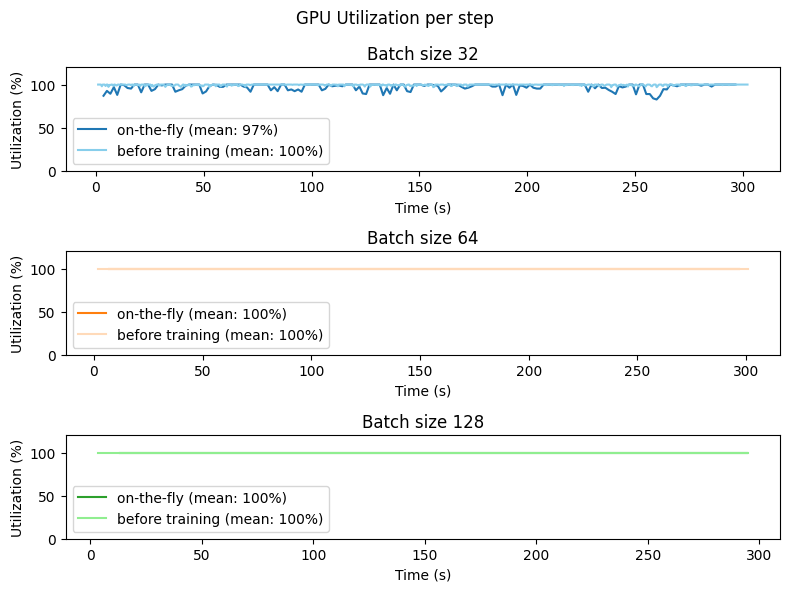

In [9]:
fig, ax = plt.subplots(3, 1, figsize=(8, 6), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        
        # average utilization
        avg = data["GPU utilization"].mean()

        ax[i].plot(data["timestamp"]/1e9, data["GPU utilization"],
                    label=f"{mode_label[m]} (mean: {avg:.0f}%)",
                    color=colours[(m, b)])
                
        ax[i].set_title(f"Batch size {b}")
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("Utilization (%)")
        ax[i].legend()
        ax[i].set_ylim(0, 120)

fig.suptitle("GPU Utilization per step")
fig.savefig(os.path.join(plot_dir, "gpu_util_step"),  dpi=300, bbox_inches="tight")

CPU utilization

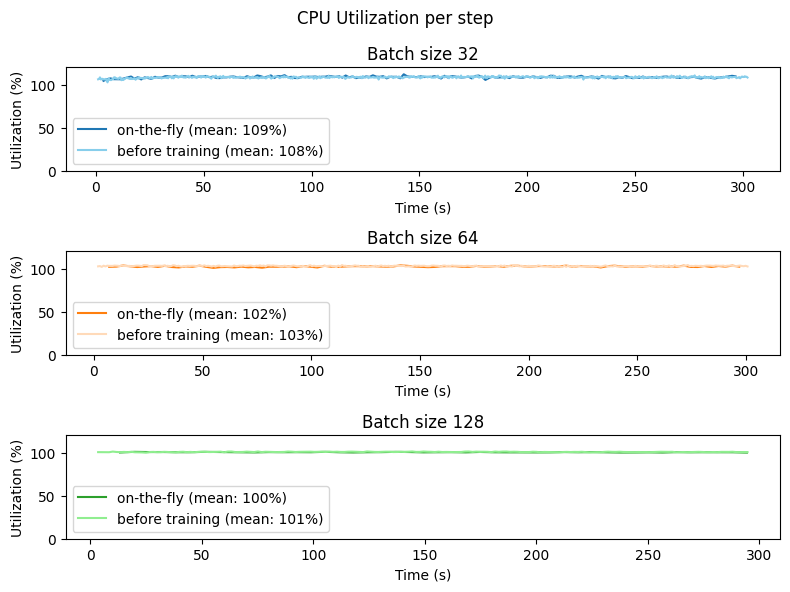

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(8, 6), layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        avg = data["CPU utilization"].mean()

        ax[i].plot(data["timestamp"]/1e9, data["CPU utilization"],
                    label=f"{mode_label[m]} (mean: {avg:.0f}%)",
                    color=colours[(m, b)])
        
        ax[i].set_title(f"Batch size {b}")
        ax[i].set_xlabel("Time (s)")
        ax[i].set_ylabel("Utilization (%)")
        ax[i].legend()
        ax[i].set_ylim(0, 120)

fig.suptitle("CPU Utilization per step")
fig.savefig(os.path.join(plot_dir, "cpu_util_step"),  dpi=300, bbox_inches="tight")

GPU memory - the measurements are in bytes

Text(0.5, 0.98, 'GPU memory per step')

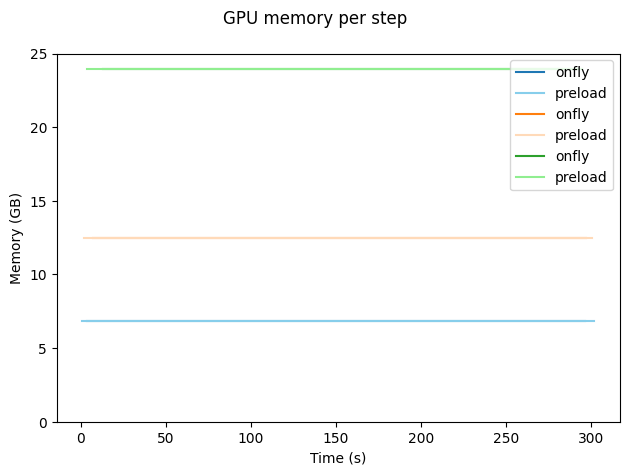

In [11]:
fig, ax = plt.subplots(layout="tight")

for i, b in enumerate(batch_sizes):
    for m in modes:
        data = data_dict[(m, b)]
        ax.plot(data["timestamp"]/1e9 ,data["GPU memory"]/1e9, label=m, color=colours[(m, b)])
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Memory (GB)")
        ax.legend()
        ax.set_ylim(0, 25)

fig.suptitle("GPU memory per step")

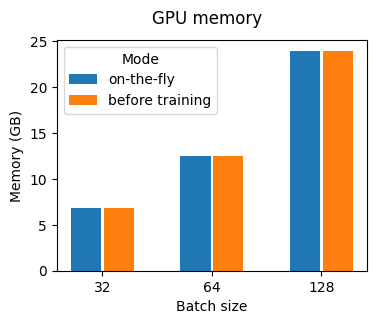

In [12]:
fig, ax = plt.subplots(figsize=(4, 3))
label_locs = np.arange(len(batch_sizes))  # the label locations
width = 0.30
multiplier = 0

for m in modes:
    memory_means = []
    for b in batch_sizes:
        memory_means.append(data_dict[(m, b)]["GPU memory"].mean()/1e9)

    offset = width * multiplier
    cont = ax.bar(label_locs+offset, memory_means, width-0.025, label=mode_label[m])
    multiplier += 1

ax.set_xticks(label_locs+width/2, batch_sizes)
ax.set_ylabel("Memory (GB)")
ax.set_xlabel("Batch size")
ax.legend(title="Mode")
fig.suptitle("GPU memory")
fig.savefig(os.path.join(plot_dir, "gpu_memory"),  dpi=300, bbox_inches="tight")